In [1]:
from rdkit import Chem
from atoMLtype.GNN.GNNfeaturizer import GraphFeaturizer
import importlib

# Load the SDF file
sdf_path = "./data/sample/sampled_dataset.sdf"
json_labels = "./data/sample/sampled_labels.json"
suppl = Chem.SDMolSupplier(sdf_path, removeHs=False)

# Initialize Featurizer
featurizer = GraphFeaturizer()

# Extract Features from First Molecule
mol = suppl[0]  # Get first molecule
if mol is not None:
    print(f"mol: {mol.GetProp('_Name')}")
    atom_features, edge_indices, bond_features = featurizer.featurize(mol)

    print("Atom Features (Node Features):")
    for i, f in enumerate(atom_features):
        print(f"Atom {i}: {f}")

    print("\nBond Features (Edge Features):")
    for i, (idx, f) in enumerate(zip(edge_indices, bond_features)):
        print(f"Bond {idx}: {f}")



mol: ZINC04600100
Atom Features (Node Features):
Atom 0: [0.      0.      0.      0.      0.      1.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      1.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      1.      1.      0.      0.      0.      0.      0.

In [2]:
from atoMLtype.GNN.GNNdataset import GNNdataset

# Initialize Dataset
dataset = GNNdataset(sdf_path,json_labels)

# Check First Graph
graph = dataset[0]
print("Graph Representation:")
print(graph)

print("\nNode Features Shape:", graph.x.shape)  # (num_nodes, num_features)
print("Edge Index Shape:", graph.edge_index.shape)  # (2, num_edges)
print("Edge Features Shape:", graph.edge_attr.shape)  # (num_edges, edge_feature_dim)


Graph Representation:
Data(x=[16, 152], edge_index=[2, 17], edge_attr=[17, 16], y=[16], y_values=[16], mol_name='ZINC04600100')

Node Features Shape: torch.Size([16, 152])
Edge Index Shape: torch.Size([2, 17])
Edge Features Shape: torch.Size([17, 16])


In [3]:
import matplotlib.pyplot as plt
import networkx as nx
import torch
from rdkit import Chem
from rdkit.Chem import Draw
from torch_geometric.utils import to_networkx

def visualize_molecular_graph(data, mol=None, atom_labels=None):
    """
    Visualizes the RDKit molecular structure next to its PyG graph representation.

    Args:
        data (torch_geometric.data.Data): PyG molecular graph.
        mol (rdkit.Chem.Mol, optional): RDKit molecule object for reference.
        atom_labels (dict, optional): Dictionary mapping atom indices to labels.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # ---- Left Side: RDKit Molecular Structure ----
    if mol:
        atom_indices = [str(atom.GetIdx()) for atom in mol.GetAtoms()]  # Get atom indices
        img = Draw.MolToImage(mol, size=(400, 400), legend="Molecular Structure")
        axes[0].imshow(img)
        axes[0].axis('off')
        axes[0].set_title("RDKit Molecular Structure")

    # ---- Right Side: PyG Graph Representation ----
    G = to_networkx(data, to_undirected=True)

    # Assign colors based on atom types
    node_colors = [data.y[i].item() if data.y is not None else 0 for i in range(data.num_nodes)]

    # Layout for better visualization
    pos = nx.spring_layout(G, seed=42)
    
    nx.draw(G, pos, with_labels=True, node_color=node_colors, cmap=plt.cm.viridis, 
            node_size=500, font_size=8, edge_color='gray', ax=axes[1])
    
    axes[1].set_title("PyG Graph Representation")
    
    plt.show()

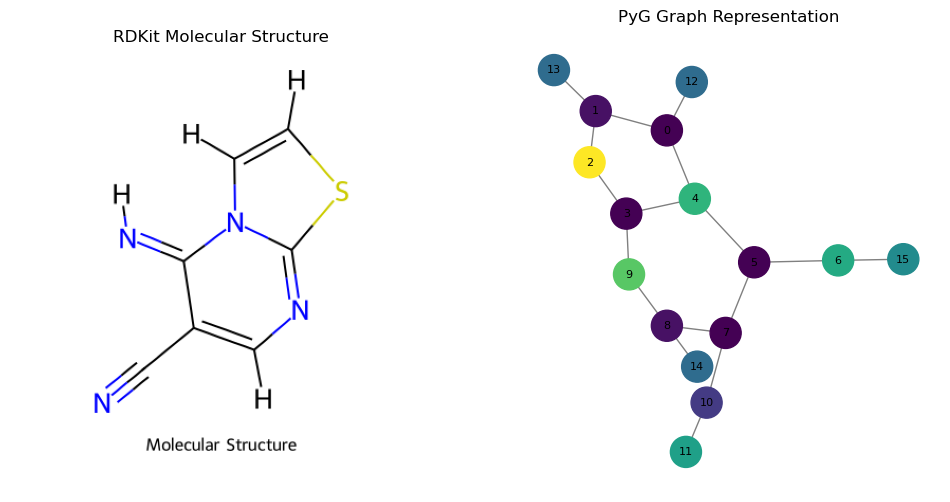

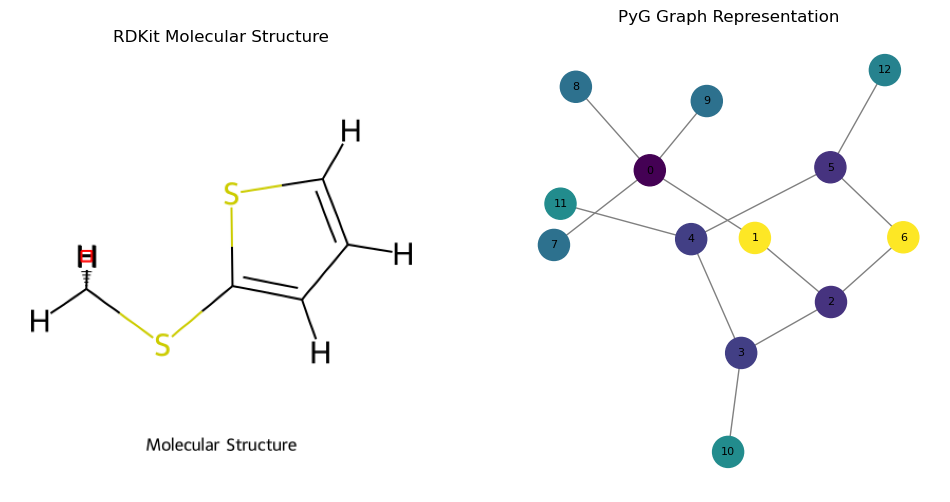

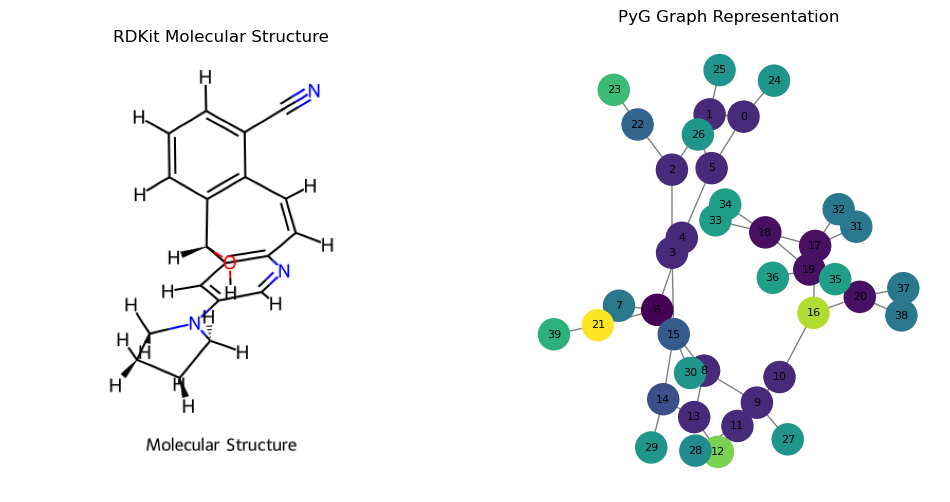

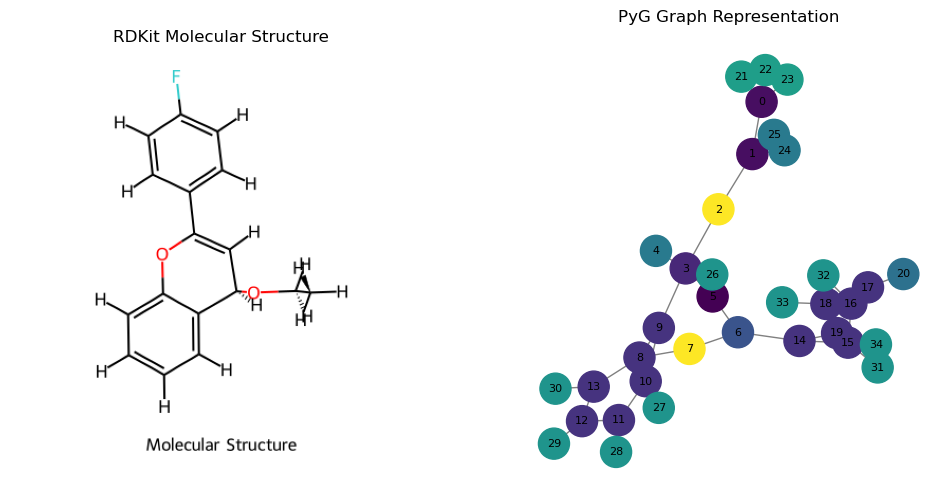

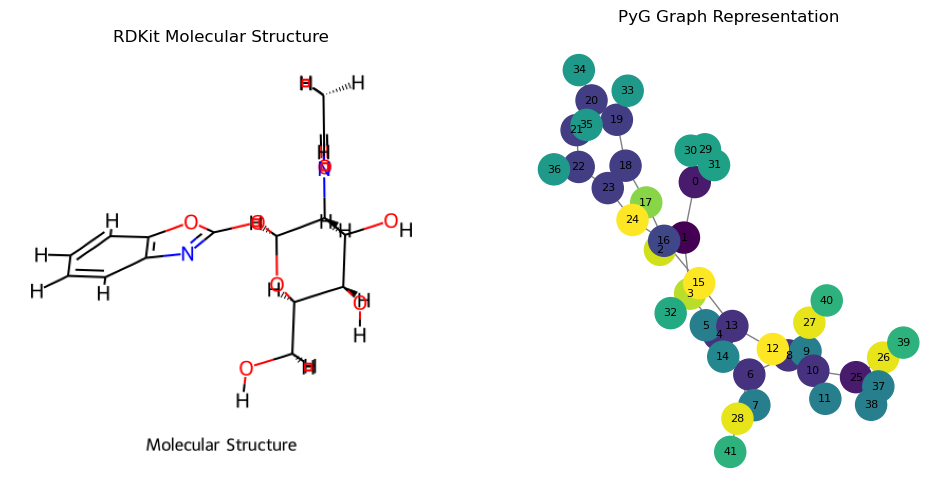

In [4]:
for mol_graph, mol_name in zip(dataset.mol_graphs, dataset.mol_names):
    mol = dataset.sdf_dataset.X_molecules.get(mol_name)
    visualize_molecular_graph(mol_graph, mol)

# Hierarchical Graph Neural Networks (HGNNs)
Hierarchical Graph Neural Networks (HGNNs) model multi-level relationships in graphs. In your case:

Molecular Graph = The full molecule where nodes are atoms and edges are bonds.
Atomic Graphs = Local subgraphs where each atom is a center node with its immediate bonded neighbors.

PyG allows hierarchical GNN modeling via pooling layers that aggregate local subgraphs into higher-level representations.

In [5]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
from rdkit.Chem import Draw

def visualize_molecular_subgraphs(data, mol=None, subgraphs=None):
    """
    Visualizes the RDKit molecular structure next to its full PyG graph representation
    and additional subgraphs, with node labels showing atomic numbers.

    Args:
        data (torch_geometric.data.Data): PyG molecular graph.
        mol (rdkit.Chem.Mol, optional): RDKit molecule object for reference.
        subgraphs (list[torch_geometric.data.Data], optional): List of PyG subgraph objects.
    """
    num_subgraphs = len(subgraphs) if subgraphs else 0
    total_plots = 2 + num_subgraphs  # RDKit + Full Graph + Subgraphs

    fig, axes = plt.subplots(1, total_plots, figsize=(6 * total_plots, 6))

    # ---- Left Side: RDKit Molecular Structure ----
    if mol:
        img = Draw.MolToImage(mol, size=(400, 400), legend="Molecular Structure")
        axes[0].imshow(img)
        axes[0].axis('off')
        axes[0].set_title("RDKit Molecular Structure")
    else:
        axes[0].axis('off')
        axes[0].set_title("No RDKit Structure Provided")

    # ---- Middle: Full PyG Graph Representation ----
    print("[DEBUG] Converting full PyG graph to NetworkX...")
    full_graph = to_networkx(data, to_undirected=True)
    print(f"[DEBUG] Full Graph Nodes: {list(full_graph.nodes())}")
    print(f"[DEBUG] Full Graph Edges: {list(full_graph.edges())}")

    pos = nx.spring_layout(full_graph, seed=42)  # Positioning for visualization

    # Extract atomic numbers from `data.y` if available
    atomic_labels = [data.y[i].item() for i in range(data.num_nodes)]

    nx.draw(full_graph, pos, with_labels=True, node_color=atomic_labels,
            node_size=500, font_size=8, edge_color="gray", ax=axes[1])
    axes[1].set_title("Full PyG Graph Representation")

    # ---- Right Side: Subgraphs ----
    if subgraphs:
        for idx, subgraph in enumerate(subgraphs):
            print(f"\n[DEBUG] Processing Subgraph {idx + 1}...")
            print(f"[DEBUG] Subgraph {idx + 1} Edge Index:\n{subgraph.edge_index}")

            sub_G = to_networkx(subgraph, to_undirected=True)
            print(f"[DEBUG] Subgraph {idx + 1} Nodes: {list(sub_G.nodes())}")
            print(f"[DEBUG] Subgraph {idx + 1} Edges: {list(sub_G.edges())}")

            sub_pos = nx.spring_layout(sub_G, seed=42)

            # Extract atomic numbers for subgraph safely
            sub_atomic_labels = [subgraph.y[i].item() for i in range(subgraph.num_nodes)]

            nx.draw(sub_G, sub_pos, with_labels=True, node_color=sub_atomic_labels, 
                    node_size=500, font_size=8, edge_color="gray", ax=axes[idx + 2])
            axes[idx + 2].set_title(f"Subgraph {idx + 1}")

    plt.show()




Graph Representation:
Data(x=[16, 152], edge_index=[2, 17], edge_attr=[17, 16], y=[16], y_values=[16], mol_name='ZINC04600100')


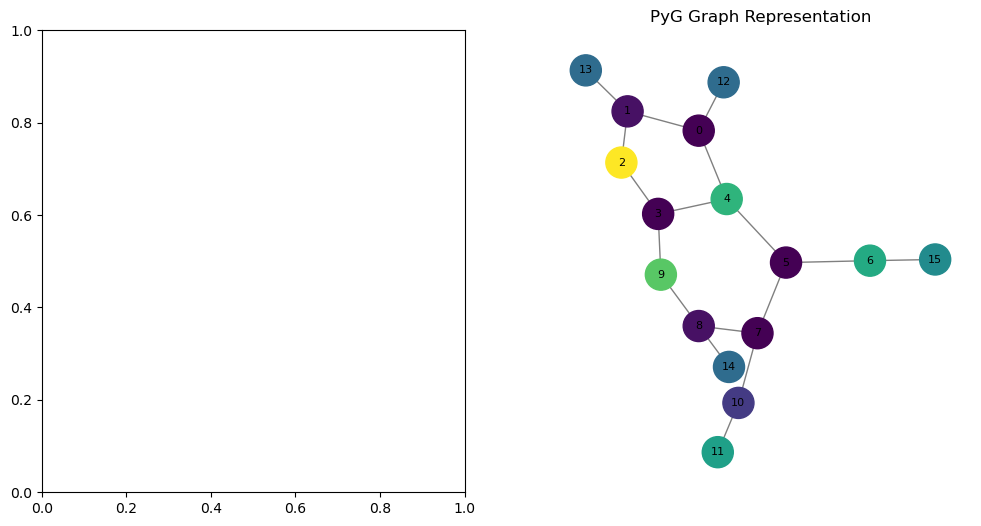


Node Features Shape: torch.Size([16, 152])
Edge Index Shape: torch.Size([2, 17])
Edge Features Shape: torch.Size([17, 16])


In [6]:
play_graph = dataset.mol_graphs[0]

print("Graph Representation:")
print(play_graph)
visualize_molecular_graph(play_graph)
print("\nNode Features Shape:", play_graph.x.shape)  # (num_nodes, num_features)
print("Edge Index Shape:", play_graph.edge_index.shape)  # (2, num_edges)
print("Edge Features Shape:", play_graph.edge_attr.shape)  # (num_edges, edge_feature_dim)

Graph Representation:
Data(x=[4, 152], edge_index=[2, 3], edge_attr=[3, 16], y=[4], y_values=[4], mol_name='ZINC04600100', central_atom_idx=0)


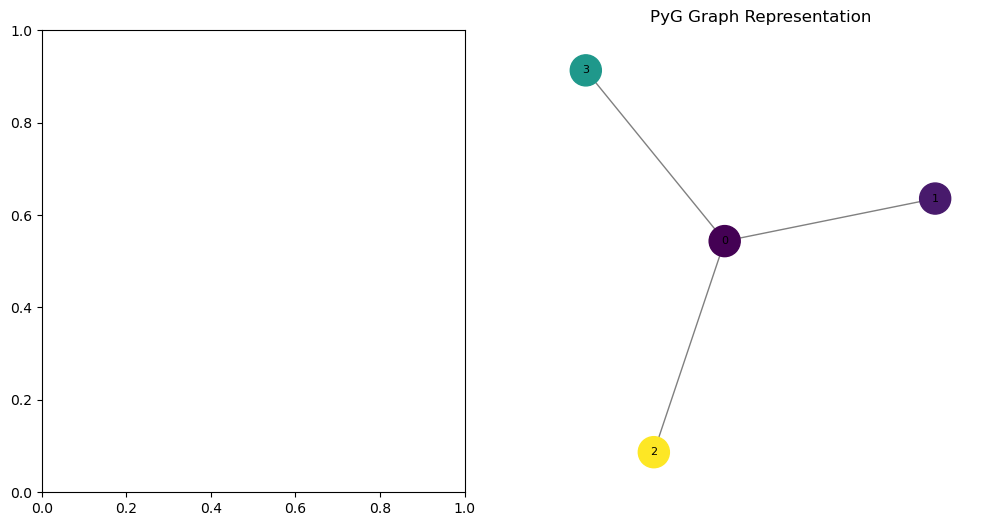


Node Features Shape: torch.Size([4, 152])
Edge Index Shape: torch.Size([2, 3])
Edge Features Shape: torch.Size([3, 16])


In [7]:
# Check First Graph
graph = dataset.dataset_subgraphs[0]
print("Graph Representation:")
print(graph)
visualize_molecular_graph(graph)
print("\nNode Features Shape:", graph.x.shape)  # (num_nodes, num_features)
print("Edge Index Shape:", graph.edge_index.shape)  # (2, num_edges)
print("Edge Features Shape:", graph.edge_attr.shape)  # (num_edges, edge_feature_dim)


# Train GNN and extract embeddings for graph clustering and similarity comparison

In [8]:
from atoMLtype.GNN.GNNmodel import GNNTrainer, BaselineGCN, BaselineGAT
from atoMLtype.GNN.GNNdataset import GNNdataset
from atoMLtype.utils.metrics import plot_atom_distribution, plot_full_confusion_matrix, plot_category_confusion_matrix
from torch.utils.data import random_split
import numpy as np
import torch

[19:35:32] Explicit valence for atom # 9 N, 5, is greater than permitted
Sanitization failed for molecule at index 2131, Name: ZINC16448882. Skipping sanitization: Explicit valence for atom # 9 N, 5, is greater than permitted
[19:35:32] Explicit valence for atom # 7 N, 5, is greater than permitted
Sanitization failed for molecule at index 2721, Name: ZINC15772239. Skipping sanitization: Explicit valence for atom # 7 N, 5, is greater than permitted
[19:35:32] Explicit valence for atom # 10 N, 5, is greater than permitted
Sanitization failed for molecule at index 3249, Name: ZINC11539132. Skipping sanitization: Explicit valence for atom # 10 N, 5, is greater than permitted
[19:35:33] Explicit valence for atom # 3 N, 5, is greater than permitted
Sanitization failed for molecule at index 5699, Name: ZINC17111082. Skipping sanitization: Explicit valence for atom # 3 N, 5, is greater than permitted
Skipping molecule ZINC59391023: Missing from JSON.
Skipping molecule ZINC00335972: Missing fro

MOLECULE DATASET
num_node_features = 152
num_y_ATs = 75
ATOM DATASET
Subgraph num_node_features = 152
FULL DATASET:


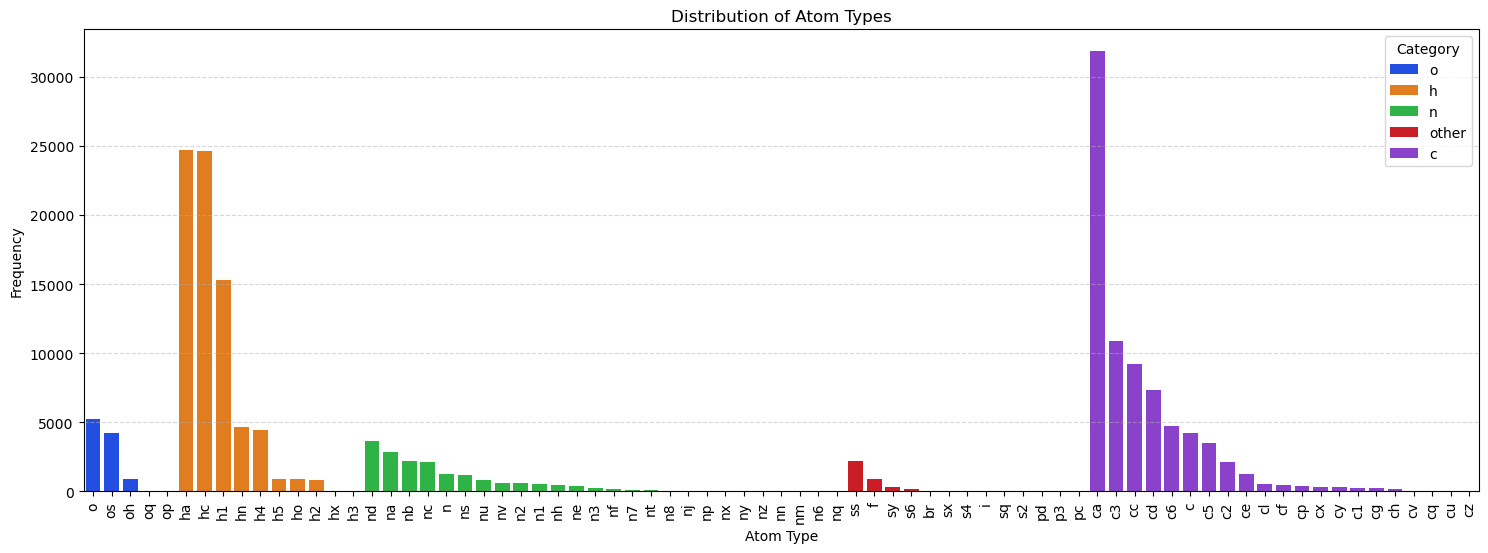

BaselineGCN - Number of parameters: 18827


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.6038 | Val Loss: 0.6036
Epoch - 20: Train Loss: 0.5615 | Val Loss: 0.5632


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.5484 | Val Loss: 0.5504
Epoch - 20: Train Loss: 0.5417 | Val Loss: 0.5440


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.5368 | Val Loss: 0.5383
Epoch - 20: Train Loss: 0.5335 | Val Loss: 0.5392


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.5316 | Val Loss: 0.5337
Epoch - 20: Train Loss: 0.5290 | Val Loss: 0.5315


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.5268 | Val Loss: 0.5338
Epoch - 20: Train Loss: 0.5248 | Val Loss: 0.5363


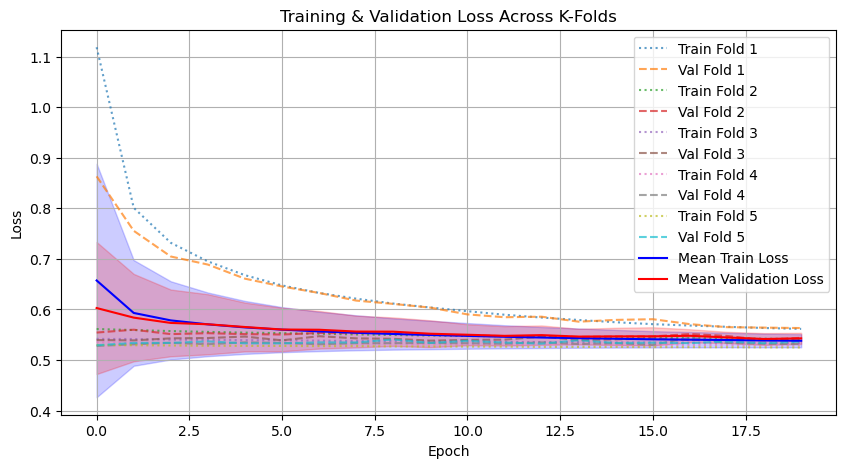

Evaluation Metrics: {'Accuracy': 0.7922019538341835, 'F1-score': 0.7782585722692323}


In [9]:
# ######Build and Train model##########

# # Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
gnn_test_dataset = GNNdataset(sdf_path, json_labels)
num_node_feat = gnn_test_dataset[0].x.shape[1]
num_y_ATs = len(set(gnn_test_dataset.all_labels))
print("MOLECULE DATASET")
print(f"num_node_features = {num_node_feat}")
print(f"num_y_ATs = {num_y_ATs}")

# Extract Subgraph Dataset
subgraphs_test_dataset = gnn_test_dataset.dataset_subgraphs
num_node_feat_sub = subgraphs_test_dataset[0].x.shape[1]

print("ATOM DATASET")
print(f"Subgraph num_node_features = {num_node_feat_sub}")

# Split Train and test dataset (95% train, 5% test)
train_size = int(0.9 * len(subgraphs_test_dataset))
test_size = len(subgraphs_test_dataset) - train_size
train_dataset, test_dataset = random_split(subgraphs_test_dataset, [train_size, test_size])

print("FULL DATASET:")
plot_atom_distribution(np.array(gnn_test_dataset.all_labels))

# Initialize baselineGNN for classification
model = BaselineGCN(num_node_features=num_node_feat, num_atom_types=num_y_ATs)
trainer = GNNTrainer(model, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=20, k_folds=5, task="classification", random_seed=21)

trainer.train()
metrics = trainer.evaluate_model(test_dataset)

y_true_labels, y_pred_labels = trainer.predict(test_dataset)

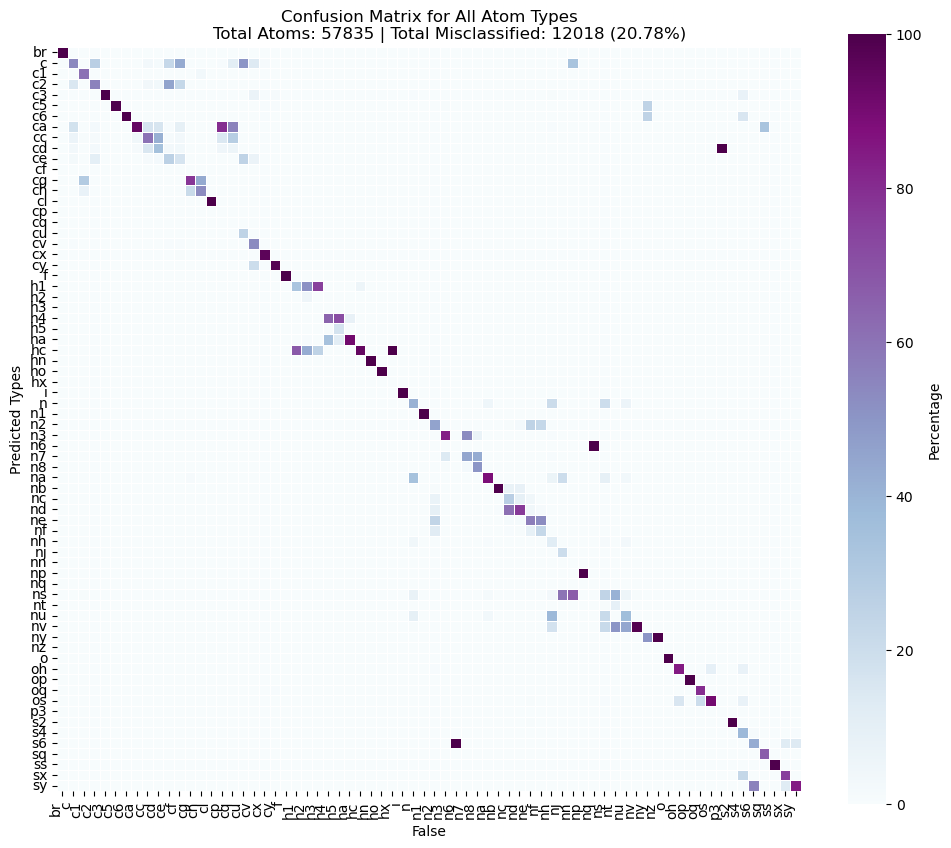

In [10]:
y_true_labels_decoded = gnn_test_dataset.label_encoder.inverse_transform(y_true_labels)
y_pred_labels_decoded = gnn_test_dataset.label_encoder.inverse_transform(y_pred_labels)
plot_full_confusion_matrix(y_true=y_true_labels_decoded, y_pred=y_pred_labels_decoded)